### 0.Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

### 1.Introduction

i. 5 примеров приминения алгоритмов ML в жизни:
1) Рекомендательные системы
2) Распознавание лиц на фото
3) Спам-фильтрация в электронной почте
4) Прогнозирование отказов оборудования на производстве
5) Диагностика заболеваний по медицинским изображениям

ii. Supervised: Classification: 2, 4, 5, 6, 8, 10, i.1, i.2, i.3, i.4, i.5\
&nbsp;&nbsp;&nbsp;&nbsp;Supervised: Regression: 1, 3, 7, i.1, i.4, i.5\
&nbsp;&nbsp;&nbsp;&nbsp;Unsupervised: Clustering: 5, 7, 9, 10, i.1, i.2, i.3, i.4, i.5\
&nbsp;&nbsp;&nbsp;&nbsp;Unsupervised: Association: 5, 7, 9, i.1, i.3, i.4, i.5\
&nbsp;&nbsp;&nbsp;&nbsp;Unsupervised: Dimensionality Reduction: 5, 6, 9, 10, i.1, i.2, i.4, i.5

iii. Multiclass (многоклассовая классификация):
Каждый объект принадлежит ровно одному из нескольких классов. Например, классификация фруктов: яблоко, груша, банан. Фрукт не может быть одновременно яблоком и грушей.\
Multilabel (многометочная классификация):
Один объект может принадлежать нескольким классам одновременно. Например, фильм может относиться к жанрам: драма, комедия, триллер. Здесь каждому объекту ставится несколько меток.

vi. Это регрессионная задача, потому что мы предсказываем вещественное число — цену квартиры или дома. Да, можно разбить диапазон цен на интервалы и присвоить каждому интервалу свой класс.

### 2.Introduction to Data Analysis

In [2]:
data = pd.read_json('../datasets/train.json')

In [3]:
data.shape

(49352, 15)

In [4]:
data.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

#### Target is Price

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


#### There are no empty columns.

In [6]:
data.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [7]:
data.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Корреляция — это статистическая мера, которая показывает, насколько две переменные связаны между собой. Обычно используется коэффициент корреляции от -1 до +1. Положительное число корреляции показывает, что если растет одна переменная, то растет и другая переменная и наоборот

In [8]:
data.reset_index(inplace=True)
df = data[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df

,bathrooms,bedrooms,interest_level,price
0,1.0,1,medium,2400
1,1.0,2,low,3800
2,1.0,2,medium,3495
3,1.5,3,medium,3000
4,1.0,0,low,2795
...,...,...,...,...
49347,1.0,3,low,2800
49348,1.0,2,medium,2395
49349,1.0,1,medium,1850
49350,1.0,2,medium,4195


### 3.Statistical Data Analysis

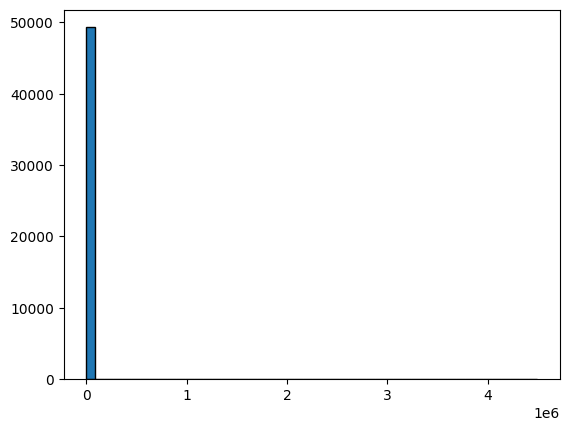

In [9]:
plt.hist(df['price'], bins=50, edgecolor='black')
plt.show()

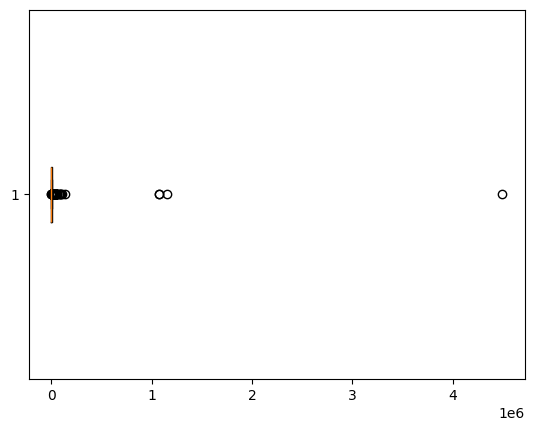

In [10]:
plt.boxplot(df['price'], vert=False)
plt.show()

In [11]:
low = df['price'].quantile(0.01)
high = df['price'].quantile(0.99)

In [12]:
df = df[(df['price'] >= low) & (df['price'] <= high)].copy()

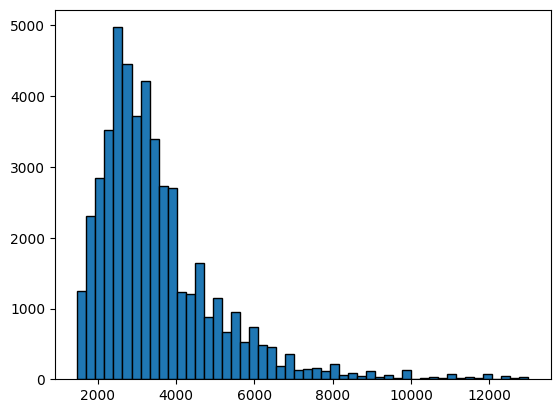

In [13]:
plt.hist(df['price'], bins=50, edgecolor='black')
plt.show()

Так как были удалены выбросы, получается лучше оценить результат

In [14]:
print(df['interest_level'].dtype)

object


In [15]:
df['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [16]:
df['interest_level'] = df['interest_level'].map({'low':0, 'medium':1, 'high':2})

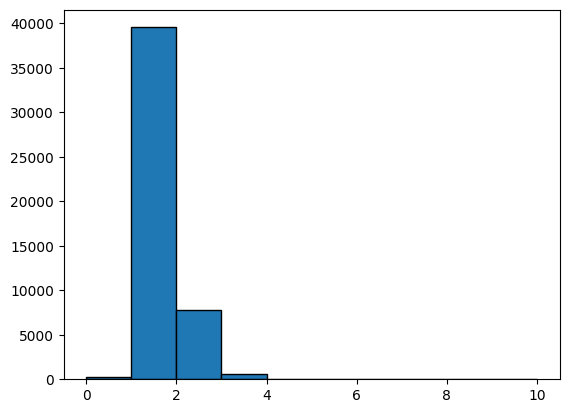

In [17]:
plt.hist(df['bathrooms'], edgecolor='black')
plt.show()

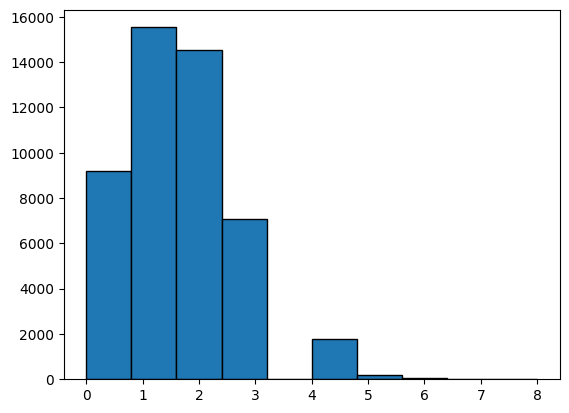

In [18]:
plt.hist(df['bedrooms'], edgecolor='black')
plt.show()

In [19]:
df.corr()

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


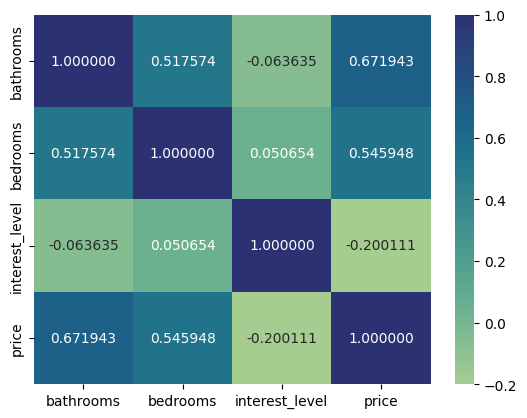

In [20]:
sns.heatmap(df.corr(), annot=True, fmt='.6f', cmap='crest')
plt.show()

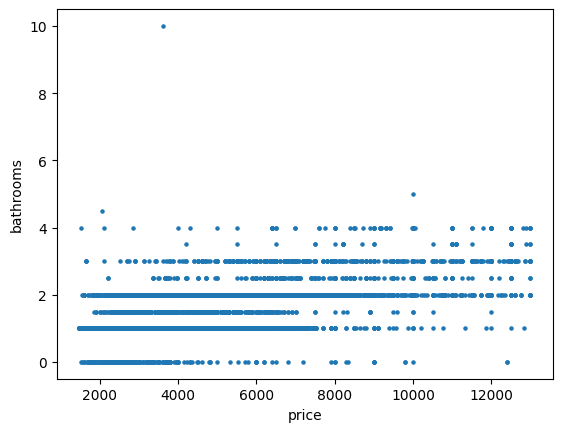

In [21]:
plt.scatter(x=df['price'], y=df['bathrooms'], s=5)
plt.xlabel('price')
plt.ylabel('bathrooms')
plt.show()

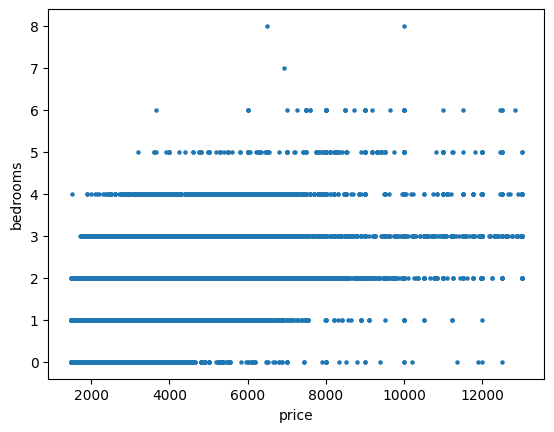

In [22]:
plt.scatter(x=df['price'], y=df['bedrooms'], s=5)
plt.xlabel('price')
plt.ylabel('bedrooms')
plt.show()

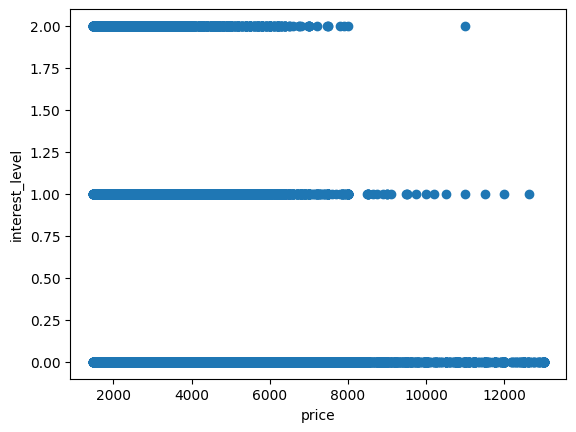

In [23]:
plt.scatter(x=df['price'], y=df['interest_level'])
plt.xlabel('price')
plt.ylabel('interest_level')
plt.show()

### 4.Creating Features

In [24]:
df_train = df[['bathrooms', 'bedrooms', 'price']]
df['bathrooms_squared'] = df['bathrooms'] ** 2
df['bedrooms_squared'] = df['bedrooms'] ** 2
df['interest_level_squared'] = df['interest_level'] ** 2

In [25]:
df.corr()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517574,-0.063635,0.671943,0.956023,0.548760,-0.059410
bedrooms,0.517574,1.000000,0.050654,0.545948,0.478817,0.928277,0.039511
interest_level,-0.063635,0.050654,1.000000,-0.200111,-0.068558,0.046340,0.944013
price,0.671943,0.545948,-0.200111,1.000000,0.648486,0.543406,-0.182672
bathrooms_squared,0.956023,0.478817,-0.068558,0.648486,1.000000,0.522227,-0.062240
bedrooms_squared,0.548760,0.928277,0.046340,0.543406,0.522227,1.000000,0.035718
interest_level_squared,-0.059410,0.039511,0.944013,-0.182672,-0.062240,0.035718,1.000000


In [26]:
data = pd.read_json('../datasets/test.json')
data.reset_index(inplace=True)
data.drop(columns=['index'], inplace=True)
df_test = data[['bathrooms', 'bedrooms', 'price']]

In [27]:
df_test = df_test[(df_test['price'] > df_test['price'].quantile(0.01)) & (df_test['price'] < df_test['price'].quantile(0.99))].copy()
df_test = df_test[(df_test['bathrooms'] > df_test['bathrooms'].quantile(0.01)) & (df_test['bathrooms'] < df_test['bathrooms'].quantile(0.99))].copy()
df_test = df_test[(df_test['bedrooms'] > df_test['bedrooms'].quantile(0.01)) & (df_test['bedrooms'] < df_test['bedrooms'].quantile(0.99))].copy()

In [28]:
X_test = df_test[['bathrooms', 'bedrooms']]
y_test = df_test['price']

In [29]:
X_train = df[['bathrooms', 'bedrooms']]
y_train = df['price']

In [30]:
poly = PolynomialFeatures(degree=10)

In [31]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

### 5.Linear regression, decision tree and naive model

In [32]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [33]:
reg = LinearRegression()
reg.fit(X_train_poly, y_train)
y_train_pred = reg.predict(X_train_poly)
y_test_pred = reg.predict(X_test_poly)

In [34]:
MAE_train = mean_absolute_error(y_train, y_train_pred)
RMSE_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

In [35]:
MAE_test = mean_absolute_error(y_test, y_test_pred)
RMSE_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [36]:
result_MAE.loc[0] = ['linear_regression', MAE_train, MAE_test]
result_RMSE.loc[0] = ['linear_regression', RMSE_train, RMSE_test]

In [37]:
regressor = DecisionTreeRegressor(random_state=21)
regressor.fit(X_train_poly, y_train)
y_train_pred = regressor.predict(X_train_poly)
y_test_pred = regressor.predict(X_test_poly)

In [38]:
MAE_train = mean_absolute_error(y_train, y_train_pred)
RMSE_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

In [39]:
MAE_test = mean_absolute_error(y_test, y_test_pred)
RMSE_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [40]:
result_MAE.loc[1] = ['decision_tree', MAE_train, MAE_test]
result_RMSE.loc[1] = ['decision_tree', RMSE_train, RMSE_test]

In [41]:
mean_train = [df_train['price'].mean()] * len(df_train)
median_train = [df_train['price'].median()] * len(df_train)

In [42]:
mean_test = [df_test['price'].mean()] * len(df_test)
median_test = [df_test['price'].median()] * len(df_test)

In [43]:
MAE_train = mean_absolute_error(y_train, mean_train)
RMSE_train = np.sqrt(mean_squared_error(y_train, mean_train))

In [44]:
MAE_test = mean_absolute_error(y_test, mean_test)
RMSE_test = np.sqrt(mean_squared_error(y_test, mean_test))

In [45]:
result_MAE.loc[2] = ['naive_mean', MAE_train, MAE_test]
result_RMSE.loc[2] = ['naive_mean', RMSE_train, RMSE_test]

In [46]:
MAE_train = mean_absolute_error(y_train, median_train)
RMSE_train = np.sqrt(mean_squared_error(y_train, median_train))

In [47]:
MAE_test = mean_absolute_error(y_test, median_test)
RMSE_test = np.sqrt(mean_squared_error(y_test, median_test))

In [48]:
result_MAE.loc[3] = ['naive_median', MAE_train, MAE_test]
result_RMSE.loc[3] = ['naive_median', RMSE_train, RMSE_test]

In [49]:
result_MAE

,model,train,test
0,linear_regression,756.040300,1198.368031
1,decision_tree,756.044735,1198.940049
2,naive_mean,1139.192515,1276.968159
3,naive_median,1086.210505,1265.536913


In [50]:
result_RMSE

,model,train,test
0,linear_regression,1077.566356,1621.483393
1,decision_tree,1077.483596,1622.361349
2,naive_mean,1597.646655,1709.845421
3,naive_median,1644.236439,1721.506700


### Лучшая модель - Decision Tree